# Utqiagvik **Uncertainty and T2m vs. other variables** Analysis 
- All data at standard resolution
- Bowhead whale hunting relationships between annual mean temperature and other environmental variables
- Notebook by Alice DuVivier (NCAR)
- September 2026

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
from glob import glob
import pop_tools
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy
import cartopy.crs as ccrs
import cmocean
import geopandas as gpd
from metpy.calc import wind_speed
from metpy.calc import wind_direction
from scipy.stats import linregress,pearsonr, t, ttest_ind

## Load Model Data
- All at standard resolution

### Temperature

### Load CESM1-LE data

In [2]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm1-le_utqiagvik/'
file_in = 'Utqiagvik_CESM1-LE_1920-2100_daily-TREFHT.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [3]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(66065,)


In [4]:
temp_cesm1le = ds.TREFHT

### Load CESM2-LE data

In [5]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-le_utqiagvik/'
file_in = 'Utqiagvik_CESM2-LE_1920-2100_daily-TREFHT.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [6]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(66065,)


In [7]:
temp_cesm2le = ds.TREFHT

### Load CESM2-CMIP5 data

In [8]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-cmip5_utqiagvik/'
file_in = 'Utqiagvik_CESM2-CMIP5_1920-2100_daily-TREFHT.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [9]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(66065,)


In [10]:
temp_cesm2cmip5 = ds.TREFHT

### Load MESACLIP data
- Load only RCP6.0 data

In [11]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/mesaclip_utqiagvik/'

In [12]:
# historical data
file_in = 'Utqiagvik_MESACLIP_HIST_monthly-TREFHT.nc'
ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

# create full range of dates at daily frequency
dates = pd.date_range(start='1/1/1920', end='12/31/2005', freq='M')
# check that the # times matches above
#print(dates.shape)

# assign the time coordinate
ds['time'] = dates

ds_hist = ds

In [13]:
# rcp6.0 data
file_in = 'Utqiagvik_MESACLIP_RCP6.0_monthly-TREFHT.nc'
ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

# create full range of dates at daily frequency
dates = pd.date_range(start='1/1/2006', end='12/31/2104', freq='M')
# check that the # times matches above
#print(dates.shape)

# assign the time coordinate
ds['time'] = dates

# clip to end at in Dec. 2100
ds = ds.where(ds.time.dt.year <= 2100, drop=True)

ds_ssp = ds

In [14]:
# concatenate data
ds = xr.concat([ds_hist,ds_ssp],dim='time')

# keep just 9 ensembles
ds = ds.isel(member_id=slice(1,10))

# keep this data
temp_mesaclip = ds.data_big_box

### Load CESM2 SSP1.26 data

In [15]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-1.26_utqiagvik/'
file_in = 'Utqiagvik_CESM2-1.26_2015-2100_daily-TREFHT.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [16]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/2015', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(31390,)


In [17]:
temp_cesm2_126 = ds.TREFHT

### Load CESM2 SSP2.45 data

In [18]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-2.45_utqiagvik/'
file_in = 'Utqiagvik_CESM2-2.45_2015-2100_daily-TREFHT.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [19]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/2015', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(31390,)


In [20]:
temp_cesm2_245 = ds.TREFHT

### Load CESM2 SSP5.85 data

In [21]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-5.85_utqiagvik/'
file_in = 'Utqiagvik_CESM2-5.85_2015-2100_daily-TREFHT.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [22]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/2015', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(31390,)


In [23]:
temp_cesm2_585 = ds.TREFHT

In [24]:
## convert all to C from K
temp_cesm1le = temp_cesm1le - 273.15
temp_cesm2le = temp_cesm2le - 273.15
temp_cesm2cmip5 = temp_cesm2cmip5 - 273.15
temp_cesm2_126 = temp_cesm2_126 - 273.15
temp_cesm2_245 = temp_cesm2_245 - 273.15
temp_cesm2_585 = temp_cesm2_585 - 273.15

### 10m wind speed

### Load CESM1-LE data

In [25]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm1-le_utqiagvik/'
file_in = 'Utqiagvik_CESM1-LE_1920-2100_daily-WSPDSRFAV.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [26]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(66065,)


In [27]:
u10_cesm1le = ds.WSPDSRFAV

### Load CESM2-LE data

In [28]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-le_utqiagvik/'
file_in = 'Utqiagvik_CESM2-LE_1920-2100_daily-U10.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [29]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(66065,)


In [30]:
u10_cesm2le = ds.U10

### Load CESM2-CMIP5 data

In [31]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-cmip5_utqiagvik/'
file_in = 'Utqiagvik_CESM2-CMIP5_1920-2100_daily-U10.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [32]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(66065,)


In [33]:
u10_cesm2cmip5 = ds.U10

### Load MESACLIP data
- Load only RCP6.0 data

In [34]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/mesaclip_utqiagvik/'

In [35]:
# historical data
file_in = 'Utqiagvik_MESACLIP_HIST_daily-U10.nc'
ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='1/1/2006', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
#print(dates.shape)

# assign the time coordinate
ds['time'] = dates

# keep this data
data_mesa_hist_ws = ds

In [36]:
# rcp6.0 data
file_in = 'Utqiagvik_MESACLIP_RCP6.0_daily-U10.nc'
ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/2006', end='1/1/2101', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

# clip to end at in Dec. 2100
ds = ds.where(ds.time.dt.year <= 2100, drop=True)

# keep this data
data_mesa_rcp60_ws = ds

(34676,)


In [37]:
# concatenate historical and rcp60
data_mesa_ws = xr.concat([data_mesa_hist_ws,data_mesa_rcp60_ws], dim='time')

In [38]:
# get three sizes to compare
u10_mesaclip = data_mesa_ws.data_big_box

### Load CESM2 SSP1.26 data

In [39]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-1.26_utqiagvik/'
file_in = 'Utqiagvik_CESM2-1.26_2015-2100_daily-U10.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [40]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/2015', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(31390,)


In [41]:
u10_cesm2_126 = ds.U10

### Load CESM2 SSP2.45 data

In [42]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-2.45_utqiagvik/'
file_in = 'Utqiagvik_CESM2-2.45_2015-2100_daily-U10.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [43]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/2015', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(31390,)


In [44]:
u10_cesm2_245 = ds.U10

### Load CESM2 SSP5.85 data

In [45]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-5.85_utqiagvik/'
file_in = 'Utqiagvik_CESM2-5.85_2015-2100_daily-U10.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [46]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/2015', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(31390,)


In [47]:
u10_cesm2_585 = ds.U10

### SIC

### Load CESM1-LE data

In [48]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm1-le_utqiagvik/'
file_in = 'Utqiagvik_CESM1-LE_1920-2100_daily-aice_d.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [49]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(66065,)


In [50]:
sic_cesm1le = ds.aice_d

### Load CESM2-LE data

In [51]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-le_utqiagvik/'
file_in = 'Utqiagvik_CESM2-LE_1920-2100_daily-aice_d.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [52]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(66065,)


In [53]:
sic_cesm2le = ds.aice_d * 100.0

### Load CESM2-CMIP5 data

In [54]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-cmip5_utqiagvik/'
file_in = 'Utqiagvik_CESM2-CMIP5_1920-2100_daily-aice_d.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [55]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(66065,)


In [56]:
sic_cesm2cmip5 = ds.aice_d * 100.0

### Load MESACLIP data
- Load only RCP6.0 data

In [57]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/mesaclip_utqiagvik/'

In [58]:
# historical data
file_in = 'Utqiagvik_MESACLIP_HIST_daily-aice_d.nc'
ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2005', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
#print(dates.shape)

# assign the time coordinate
ds['time'] = dates

# keep this data
data_mesa_hist_sic = ds

In [59]:
# rcp6.0 data
file_in = 'Utqiagvik_MESACLIP_RCP6.0_daily-aice_d.nc'
ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/2006', end='12/31/2104', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
#print(dates.shape)

# assign the time coordinate
ds['time'] = dates

# clip to end at in Dec. 2100
ds = ds.where(ds.time.dt.year <= 2100, drop=True)

# keep this data
data_mesa_rcp60_sic = ds

In [60]:
# concatenate historical and rcp60 but have to drop one ensemble member from future 
data_mesa_rcp60_sic = data_mesa_rcp60_sic.isel(member_id=slice(1,10))
data_mesa_sic = xr.concat([data_mesa_hist_sic,data_mesa_rcp60_sic], dim='time')

In [61]:
# keep this data
sic_mesaclip = data_mesa_sic.data_big_box

### Load CESM2 SSP1.26 data

In [62]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-1.26_utqiagvik/'
file_in = 'Utqiagvik_CESM2-1.26_2015-2100_daily-aice_d.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [63]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/2015', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(31390,)


In [64]:
sic_cesm2_126 = ds.aice_d * 100.0

### Load CESM2 SSP2.45 data

In [65]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-2.45_utqiagvik/'
file_in = 'Utqiagvik_CESM2-2.45_2015-2100_daily-aice_d.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [66]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/2015', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(31390,)


In [67]:
sic_cesm2_245 = ds.aice_d * 100.0

### Load CESM2 SSP5.85 data

In [68]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-5.85_utqiagvik/'
file_in = 'Utqiagvik_CESM2-5.85_2015-2100_daily-aice_d.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [69]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/2015', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(31390,)


In [70]:
sic_cesm2_585 = ds.aice_d * 100.0

### SIT

### Load CESM1-LE data

In [71]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm1-le_utqiagvik/'
file_in = 'Utqiagvik_CESM1-LE_1920-2100_daily-hi_d.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [72]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(66065,)


In [73]:
sit_cesm1le = ds.hi_d

### Load CESM2-LE data

In [74]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-le_utqiagvik/'
file_in = 'Utqiagvik_CESM2-LE_1920-2100_daily-hi_d.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [75]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(66065,)


In [76]:
sit_cesm2le = ds.hi_d

### Load CESM2-CMIP5 data

In [77]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-cmip5_utqiagvik/'
file_in = 'Utqiagvik_CESM2-CMIP5_1920-2100_daily-hi_d.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [78]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(66065,)


In [79]:
sit_cesm2cmip5 = ds.hi_d

### Load MESACLIP data
- Load only RCP6.0 data

In [80]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/mesaclip_utqiagvik/'

In [81]:
# historical data
file_in = 'Utqiagvik_MESACLIP_HIST_daily-hi_d.nc'
ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2005', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
#print(dates.shape)

# assign the time coordinate
ds['time'] = dates

# keep this data
data_mesa_hist_sit = ds

In [82]:
# rcp6.0 data
file_in = 'Utqiagvik_MESACLIP_RCP6.0_daily-hi_d.nc'
ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/2006', end='12/31/2104', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
#print(dates.shape)

# assign the time coordinate
ds['time'] = dates

# clip to end at in Dec. 2100
ds = ds.where(ds.time.dt.year <= 2100, drop=True)

# keep this data
data_mesa_rcp60_sit = ds

In [83]:
# concatenate historical and rcp60 but have to drop one ensemble member from future 
data_mesa_rcp60_sit = data_mesa_rcp60_sit.isel(member_id=slice(1,10))
data_mesa_sit = xr.concat([data_mesa_hist_sit,data_mesa_rcp60_sit], dim='time')

In [84]:
# keep this data
sit_mesaclip = data_mesa_sit.data_big_box

### Load CESM2 SSP1.26 data

In [85]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-1.26_utqiagvik/'
file_in = 'Utqiagvik_CESM2-1.26_2015-2100_daily-hi_d.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [86]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/2015', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(31390,)


In [87]:
sit_cesm2_126 = ds.hi_d

### Load CESM2 SSP2.45 data

In [88]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-2.45_utqiagvik/'
file_in = 'Utqiagvik_CESM2-2.45_2015-2100_daily-hi_d.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [89]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/2015', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(31390,)


In [90]:
sit_cesm2_245 = ds.hi_d

### Load CESM2 SSP5.85 data

In [91]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-5.85_utqiagvik/'
file_in = 'Utqiagvik_CESM2-5.85_2015-2100_daily-hi_d.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [92]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/2015', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(31390,)


In [93]:
sit_cesm2_585 = ds.hi_d

## Get the different numbers of ensembles
- Will need this later

In [94]:
# total ensemble members - will need this later
nens_cesm1le = len(temp_cesm1le.member_id)
print(nens_cesm1le)
nens_cesm2le = len(temp_cesm2le.member_id)
print(nens_cesm2le)
nens_cesm2cmip5 = len(temp_cesm2cmip5.member_id)
print(nens_cesm2cmip5)
nens_mesaclip = len(temp_mesaclip.member_id)
print(nens_mesaclip)
nens_cesm2_126 = len(temp_cesm2_126.member_id)
print(nens_cesm2_126)
nens_cesm2_245 = len(temp_cesm2_245.member_id)
print(nens_cesm2_245)
nens_cesm2_585 = len(temp_cesm2_585.member_id)
print(nens_cesm2_585)

35
50
15
9
3
3
3


## Process Annual Mean temperature data
- Timeseries: We need to first calculate the annual mean from daily data. Then from the annual mean temperatures for each ensemble member, we calculate mean and standard deviation. If we use daily data and average across everything then the variance is huge because of the annual cycle.

In [95]:
# CESM1-LE
data_model = temp_cesm1le

# calculate annual means
temp_cesm1le_yearly = data_model.groupby('time.year').mean(dim='time')

In [96]:
# CESM2-LE
data_model = temp_cesm2le

# calculate annual means
temp_cesm2le_yearly = data_model.groupby('time.year').mean(dim='time')

In [97]:
# CESM2-CMIP5
data_model = temp_cesm2cmip5

# calculate annual means
temp_cesm2cmip5_yearly = data_model.groupby('time.year').mean(dim='time')

In [98]:
# CESM2-CMIP5
data_model = temp_mesaclip

# calculate annual means
temp_mesaclip_yearly = data_model.groupby('time.year').mean(dim='time')

In [99]:
# CESM2-1.26
data_model = temp_cesm2_126

# calculate annual means
temp_cesm2_126_yearly = data_model.groupby('time.year').mean(dim='time')

In [100]:
# CESM2-2.45
data_model = temp_cesm2_245

# calculate annual means
temp_cesm2_245_yearly = data_model.groupby('time.year').mean(dim='time')

In [101]:
# CESM2-5.85
data_model = temp_cesm2_585

# calculate annual means
temp_cesm2_585_yearly = data_model.groupby('time.year').mean(dim='time')

## Process Spring SIC Model Data
- Two calculations:
   - Calculate the spring mean across all days and ensembles for timeseries plot
   - Calculate the annual frequency of times below SIC thresholds for each ensemble member and each year. Thus, total number of points to plot will be nens*nyrs. This will be in the scatter plot against temperature

In [102]:
# days are all days in April and May
ndays_spr = 30 + 31

In [103]:
# set thresholds
thresh1 = 85.0

In [104]:
# subset to just this season
sic_cesm1le_seas = sic_cesm1le.isel(time=sic_cesm1le.time.dt.month.isin([3,4]))
sic_cesm2le_seas = sic_cesm2le.isel(time=sic_cesm2le.time.dt.month.isin([3,4]))
sic_cesm2cmip5_seas = sic_cesm2cmip5.isel(time=sic_cesm2cmip5.time.dt.month.isin([3,4]))
sic_mesaclip_seas = sic_mesaclip.isel(time=sic_mesaclip.time.dt.month.isin([3,4]))
sic_cesm2_126_seas = sic_cesm2_126.isel(time=sic_cesm2_126.time.dt.month.isin([3,4]))
sic_cesm2_245_seas = sic_cesm2_245.isel(time=sic_cesm2_245.time.dt.month.isin([3,4]))
sic_cesm2_585_seas = sic_cesm2_585.isel(time=sic_cesm2_585.time.dt.month.isin([3,4]))

In [105]:
# CESM1-LE
data_model = sic_cesm1le_seas
times_tot = ndays_spr*nens_cesm1le

# group by year
sic_cesm1le_yearly = data_model.groupby('time.year').mean(dim='time')

# get frequency per year where it's below a threshold value
exceed_count = (data_model < thresh1).groupby('time.year').sum(dim=['time','member_id'])
sic_thresh1_cesm1le = 100.0 * (exceed_count/times_tot)

In [106]:
# CESM2-LE
data_model = sic_cesm2le_seas
times_tot = ndays_spr*nens_cesm2le

# group by year
sic_cesm2le_yearly = data_model.groupby('time.year').mean(dim='time')

# get frequency per year where it's below a threshold value
exceed_count = (data_model < thresh1).groupby('time.year').sum(dim=['time','member_id'])
sic_thresh1_cesm2le = 100.0 * (exceed_count/times_tot)

In [107]:
# CESM2-CMIP5
data_model = sic_cesm2cmip5_seas
times_tot = ndays_spr*nens_cesm2cmip5

# group by year
sic_cesm2cmip5_yearly = data_model.groupby('time.year').mean(dim='time')

# get frequency per year where it's below a threshold value
exceed_count = (data_model < thresh1).groupby('time.year').sum(dim=['time','member_id'])
sic_thresh1_cesm2cmip5 = 100.0 * (exceed_count/times_tot)

In [108]:
# MESACLIP
data_model = sic_mesaclip_seas
times_tot = ndays_spr*nens_mesaclip

# group by year
sic_mesaclip_yearly = data_model.groupby('time.year').mean(dim='time')

# get frequency per year where it's below a threshold value
exceed_count = (data_model < thresh1).groupby('time.year').sum(dim=['time','member_id'])
sic_thresh1_mesaclip = 100.0 * (exceed_count/times_tot)

In [109]:
# CESM2-1.26
data_model = sic_cesm2_126_seas
times_tot = ndays_spr*nens_cesm2_126

# group by year
sic_cesm2_126_yearly = data_model.groupby('time.year').mean(dim='time')

# get frequency per year where it's below a threshold value
exceed_count = (data_model < thresh1).groupby('time.year').sum(dim=['time','member_id'])
sic_thresh1_cesm2_126 = 100.0 * (exceed_count/times_tot)

In [110]:
# CESM2-2.45
data_model = sic_cesm2_245_seas
times_tot = ndays_spr*nens_cesm2_245

# group by year
sic_cesm2_245_yearly = data_model.groupby('time.year').mean(dim='time')

# get frequency per year where it's below a threshold value
exceed_count = (data_model < thresh1).groupby('time.year').sum(dim=['time','member_id'])
sic_thresh1_cesm2_245 = 100.0 * (exceed_count/times_tot)

In [111]:
# CESM2-5.85
data_model = sic_cesm2_585_seas
times_tot = ndays_spr*nens_cesm2_585

# group by year
sic_cesm2_585_yearly = data_model.groupby('time.year').mean(dim='time')

# get frequency per year where it's below a threshold value
exceed_count = (data_model < thresh1).groupby('time.year').sum(dim=['time','member_id'])
sic_thresh1_cesm2_585 = 100.0 * (exceed_count/times_tot)

## Process Spring SIT Model Data
- Two calculations:
   - Calculate the spring mean across all days and ensembles for timeseries plot
   - Calculate the annual frequency of times below SIT thresholds for each ensemble member and each year. Thus, total number of points to plot will be nens*nyrs. This will be in the scatter plot against temperature

In [112]:
# days are all days in April and May
ndays_spr = 30 + 31

In [113]:
# set thresholds
thresh1 = 2.0

In [114]:
# subset to just this season
sit_cesm1le_seas = sit_cesm1le.isel(time=sit_cesm1le.time.dt.month.isin([3,4]))
sit_cesm2le_seas = sit_cesm2le.isel(time=sit_cesm2le.time.dt.month.isin([3,4]))
sit_cesm2cmip5_seas = sit_cesm2cmip5.isel(time=sit_cesm2cmip5.time.dt.month.isin([3,4]))
sit_mesaclip_seas = sit_mesaclip.isel(time=sit_mesaclip.time.dt.month.isin([3,4]))
sit_cesm2_126_seas = sit_cesm2_126.isel(time=sit_cesm2_126.time.dt.month.isin([3,4]))
sit_cesm2_245_seas = sit_cesm2_245.isel(time=sit_cesm2_245.time.dt.month.isin([3,4]))
sit_cesm2_585_seas = sit_cesm2_585.isel(time=sit_cesm2_585.time.dt.month.isin([3,4]))

In [115]:
# CESM1-LE
data_model = sit_cesm1le_seas
times_tot = ndays_spr*nens_cesm1le

# group by year
sit_cesm1le_yearly = data_model.groupby('time.year').mean(dim='time')

# get frequency per year where it's below a threshold value
exceed_count = (data_model < thresh1).groupby('time.year').sum(dim=['time','member_id'])
sit_thresh1_cesm1le = 100.0 * (exceed_count/times_tot)

In [116]:
# CESM2-LE
data_model = sit_cesm2le_seas
times_tot = ndays_spr*nens_cesm2le

# group by year
sit_cesm2le_yearly = data_model.groupby('time.year').mean(dim='time')

# get frequency per year where it's below a threshold value
exceed_count = (data_model < thresh1).groupby('time.year').sum(dim=['time','member_id'])
sit_thresh1_cesm2le = 100.0 * (exceed_count/times_tot)

In [117]:
# CESM2-CMIP5
data_model = sit_cesm2cmip5_seas
times_tot = ndays_spr*nens_cesm2cmip5

# group by year
sit_cesm2cmip5_yearly = data_model.groupby('time.year').mean(dim='time')

# get frequency per year where it's below a threshold value
exceed_count = (data_model < thresh1).groupby('time.year').sum(dim=['time','member_id'])
sit_thresh1_cesm2cmip5 = 100.0 * (exceed_count/times_tot)

In [118]:
# MESACLIP
data_model = sit_mesaclip_seas
times_tot = ndays_spr*nens_mesaclip

# group by year
sit_mesaclip_yearly = data_model.groupby('time.year').mean(dim='time')

# get frequency per year where it's below a threshold value
exceed_count = (data_model < thresh1).groupby('time.year').sum(dim=['time','member_id'])
sit_thresh1_mesaclip = 100.0 * (exceed_count/times_tot)

In [119]:
# CESM2-1.26
data_model = sit_cesm2_126_seas
times_tot = ndays_spr*nens_cesm2_126

# group by year
sit_cesm2_126_yearly = data_model.groupby('time.year').mean(dim='time')

# get frequency per year where it's below a threshold value
exceed_count = (data_model < thresh1).groupby('time.year').sum(dim=['time','member_id'])
sit_thresh1_cesm2_126 = 100.0 * (exceed_count/times_tot)

In [120]:
# CESM2-2.45
data_model = sit_cesm2_245_seas
times_tot = ndays_spr*nens_cesm2_245

# group by year
sit_cesm2_245_yearly = data_model.groupby('time.year').mean(dim='time')

# get frequency per year where it's below a threshold value
exceed_count = (data_model < thresh1).groupby('time.year').sum(dim=['time','member_id'])
sit_thresh1_cesm2_245 = 100.0 * (exceed_count/times_tot)

In [121]:
# CESM2-5.85
data_model = sit_cesm2_585_seas
times_tot = ndays_spr*nens_cesm2_585

# group by year
sit_cesm2_585_yearly = data_model.groupby('time.year').mean(dim='time')

# get frequency per year where it's below a threshold value
exceed_count = (data_model < thresh1).groupby('time.year').sum(dim=['time','member_id'])
sit_thresh1_cesm2_585 = 100.0 * (exceed_count/times_tot)

## Process Autumn WS Model Data
- Two calculations:
   - Calculate the spring mean across all days and ensembles for timeseries plot
   - Calculate the annual frequency of times above ws thresholds for each ensemble member and each year. Thus, total number of points to plot will be nens*nyrs. This will be in the scatter plot against temperature

In [122]:
# days are all days in SON
ndays_fall = 30 + 31 + 30

In [123]:
# set thresholds
thresh1 = 11.0

In [124]:
# subset to just this season
u10_cesm1le_seas = u10_cesm1le.isel(time=u10_cesm1le.time.dt.month.isin([9,10,11]))
u10_cesm2le_seas = u10_cesm2le.isel(time=u10_cesm2le.time.dt.month.isin([9,10,11]))
u10_cesm2cmip5_seas = u10_cesm2cmip5.isel(time=u10_cesm2cmip5.time.dt.month.isin([9,10,11]))
u10_mesaclip_seas = u10_mesaclip.isel(time=u10_mesaclip.time.dt.month.isin([9,10,11]))
u10_cesm2_126_seas = u10_cesm2_126.isel(time=u10_cesm2_126.time.dt.month.isin([9,10,11]))
u10_cesm2_245_seas = u10_cesm2_245.isel(time=u10_cesm2_245.time.dt.month.isin([9,10,11]))
u10_cesm2_585_seas = u10_cesm2_585.isel(time=u10_cesm2_585.time.dt.month.isin([9,10,11]))

In [125]:
# CESM1-LE
data_model = u10_cesm1le_seas
times_tot = ndays_spr*nens_cesm1le

# group by year
u10_cesm1le_yearly = data_model.groupby('time.year').mean(dim='time')

# get frequency per year where it's below a threshold value
exceed_count = (data_model < thresh1).groupby('time.year').sum(dim=['time','member_id'])
u10_thresh1_cesm1le = 100.0 * (exceed_count/times_tot)

In [126]:
# CESM2-LE
data_model = u10_cesm2le_seas
times_tot = ndays_spr*nens_cesm2le

# group by year
u10_cesm2le_yearly = data_model.groupby('time.year').mean(dim='time')

# get frequency per year where it's below a threshold value
exceed_count = (data_model < thresh1).groupby('time.year').sum(dim=['time','member_id'])
u10_thresh1_cesm2le = 100.0 * (exceed_count/times_tot)

In [127]:
# CESM2-CMIP5
data_model = u10_cesm2cmip5_seas
times_tot = ndays_spr*nens_cesm2cmip5

# group by year
u10_cesm2cmip5_yearly = data_model.groupby('time.year').mean(dim='time')

# get frequency per year where it's below a threshold value
exceed_count = (data_model < thresh1).groupby('time.year').sum(dim=['time','member_id'])
u10_thresh1_cesm2cmip5 = 100.0 * (exceed_count/times_tot)

In [128]:
# MESACLIP
data_model = u10_mesaclip_seas
times_tot = ndays_spr*nens_mesaclip

# group by year
u10_mesaclip_yearly = data_model.groupby('time.year').mean(dim='time')

# get frequency per year where it's below a threshold value
exceed_count = (data_model < thresh1).groupby('time.year').sum(dim=['time','member_id'])
u10_thresh1_mesaclip = 100.0 * (exceed_count/times_tot)

In [129]:
# CESM2-1.26
data_model = u10_cesm2_126_seas
times_tot = ndays_spr*nens_cesm2_126

# group by year
u10_cesm2_126_yearly = data_model.groupby('time.year').mean(dim='time')

# get frequency per year where it's below a threshold value
exceed_count = (data_model < thresh1).groupby('time.year').sum(dim=['time','member_id'])
u10_thresh1_cesm2_126 = 100.0 * (exceed_count/times_tot)

In [130]:
# CESM2-2.45
data_model = u10_cesm2_245_seas
times_tot = ndays_spr*nens_cesm2_245

# group by year
u10_cesm2_245_yearly = data_model.groupby('time.year').mean(dim='time')

# get frequency per year where it's below a threshold value
exceed_count = (data_model < thresh1).groupby('time.year').sum(dim=['time','member_id'])
u10_thresh1_cesm2_245 = 100.0 * (exceed_count/times_tot)

In [131]:
# CESM2-5.85
data_model = u10_cesm2_585_seas
times_tot = ndays_spr*nens_cesm2_585

# group by year
u10_cesm2_585_yearly = data_model.groupby('time.year').mean(dim='time')

# get frequency per year where it's below a threshold value
exceed_count = (data_model < thresh1).groupby('time.year').sum(dim=['time','member_id'])
u10_thresh1_cesm2_585 = 100.0 * (exceed_count/times_tot)

## Calculate uncertainty
- Follow Hawkins and Sutton method that Dave Bonan also used. Also used Claude for some coding assistance.
- Exclude MESACLIP since it doesn't have a good parallel for model or scenario.
- Note that all models need to have the same time dimension, so we'll need to clip some of the data

### Scenario uncertainty -- fixed model (CESM2)
- Use CESM2-1.25, CESM2-2.45, CESM2-LE (3.70), and CESM2-5.85.
- Try both claude method and Dave B's method

In [132]:
### Temperature
data1 = temp_cesm2_126_yearly
data2 = temp_cesm2_245_yearly
data3 = temp_cesm2le_yearly
data4 = temp_cesm2_585_yearly
# clip data to just 2015 and onward
data1 = data1.where(data1.year >= 2015, drop=True)
data2 = data2.where(data2.year >= 2015, drop=True)
data3 = data3.where(data3.year >= 2015, drop=True)
data4 = data4.where(data4.year >= 2015, drop=True)
# check number of years
nyrs = len(data1.year)
#print(nyrs)

# Calculate uncertainty
data_scenario = np.zeros((4,nyrs))
data_scenario[0,:] = (np.nanmean(data1,axis=0)+np.nanmean(data1.T,axis=1))/2
data_scenario[1,:] = (np.nanmean(data2,axis=0)+np.nanmean(data2.T,axis=1))/2
data_scenario[2,:] = (np.nanmean(data3,axis=0)+np.nanmean(data3.T,axis=1))/2
data_scenario[3,:] = (np.nanmean(data4,axis=0)+np.nanmean(data4.T,axis=1))/2

# Get variance across scenarios
scenario_var_temp = np.std(data_scenario,axis=0)**2

In [133]:
### SIT
data1 = sit_cesm2_126_yearly
data2 = sit_cesm2_245_yearly
data3 = sit_cesm2le_yearly
data4 = sit_cesm2_585_yearly
# clip data to just 2015 and onward
data1 = data1.where(data1.year >= 2015, drop=True)
data2 = data2.where(data2.year >= 2015, drop=True)
data3 = data3.where(data3.year >= 2015, drop=True)
data4 = data4.where(data4.year >= 2015, drop=True)
# check number of years
nyrs = len(data1.year)
#print(nyrs)

# Calculate uncertainty
data_scenario = np.zeros((4,nyrs))
data_scenario[0,:] = (np.nanmean(data1,axis=0)+np.nanmean(data1.T,axis=1))/2
data_scenario[1,:] = (np.nanmean(data2,axis=0)+np.nanmean(data2.T,axis=1))/2
data_scenario[2,:] = (np.nanmean(data3,axis=0)+np.nanmean(data3.T,axis=1))/2
data_scenario[3,:] = (np.nanmean(data4,axis=0)+np.nanmean(data4.T,axis=1))/2

# Get variance across scenarios
scenario_var_sit = np.std(data_scenario,axis=0)**2

In [134]:
### SIC
data1 = sic_cesm2_126_yearly
data2 = sic_cesm2_245_yearly
data3 = sic_cesm2le_yearly
data4 = sic_cesm2_585_yearly
# clip data to just 2015 and onward
data1 = data1.where(data1.year >= 2015, drop=True)
data2 = data2.where(data2.year >= 2015, drop=True)
data3 = data3.where(data3.year >= 2015, drop=True)
data4 = data4.where(data4.year >= 2015, drop=True)
# check number of years
nyrs = len(data1.year)
#print(nyrs)

# Calculate uncertainty
data_scenario = np.zeros((4,nyrs))
data_scenario[0,:] = (np.nanmean(data1,axis=0)+np.nanmean(data1.T,axis=1))/2
data_scenario[1,:] = (np.nanmean(data2,axis=0)+np.nanmean(data2.T,axis=1))/2
data_scenario[2,:] = (np.nanmean(data3,axis=0)+np.nanmean(data3.T,axis=1))/2
data_scenario[3,:] = (np.nanmean(data4,axis=0)+np.nanmean(data4.T,axis=1))/2

# Get variance across scenarios
scenario_var_sic = np.std(data_scenario,axis=0)**2

In [135]:
### WS
data1 = u10_cesm2_126_yearly
data2 = u10_cesm2_245_yearly
data3 = u10_cesm2le_yearly
data4 = u10_cesm2_585_yearly
# clip data to just 2015 and onward
data1 = data1.where(data1.year >= 2015, drop=True)
data2 = data2.where(data2.year >= 2015, drop=True)
data3 = data3.where(data3.year >= 2015, drop=True)
data4 = data4.where(data4.year >= 2015, drop=True)
# check number of years
nyrs = len(data1.year)
#print(nyrs)

# Calculate uncertainty
data_scenario = np.zeros((4,nyrs))
data_scenario[0,:] = (np.nanmean(data1,axis=0)+np.nanmean(data1.T,axis=1))/2
data_scenario[1,:] = (np.nanmean(data2,axis=0)+np.nanmean(data2.T,axis=1))/2
data_scenario[2,:] = (np.nanmean(data3,axis=0)+np.nanmean(data3.T,axis=1))/2
data_scenario[3,:] = (np.nanmean(data4,axis=0)+np.nanmean(data4.T,axis=1))/2

# Get variance across scenarios
scenario_var_u10 = np.std(data_scenario,axis=0)**2

### Model uncertainty -- fixed forcing (RCP8.5)
- Use CESM1-LE and CESM2-CMIP5
- Having just two models is not ideal, but it's what we had

In [136]:
### Temperature
data1 = temp_cesm1le_yearly
data2 = temp_cesm2cmip5_yearly
# clip data to just 2015 and onward
data1 = data1.where(data1.year >= 2015, drop=True)
data2 = data2.where(data2.year >= 2015, drop=True)
# check number of years
nyrs = len(data1.year)
#print(nyrs)

# Calculate uncertainty
data_model = np.zeros((2,nyrs))
data_model[0,:] = np.nanmean(data1,axis=0)
data_model[1,:] = np.nanmean(data2,axis=0)

# Get variance across models
model_var_temp = np.std(data_model,axis=0)**2

In [137]:
### SIT
data1 = sit_cesm1le_yearly
data2 = sit_cesm2cmip5_yearly
# clip data to just 2015 and onward
data1 = data1.where(data1.year >= 2015, drop=True)
data2 = data2.where(data2.year >= 2015, drop=True)
# check number of years
nyrs = len(data1.year)
#print(nyrs)

# Calculate uncertainty
data_model = np.zeros((2,nyrs))
data_model[0,:] = np.nanmean(data1,axis=0)
data_model[1,:] = np.nanmean(data2,axis=0)

# Get variance across models
model_var_sit = np.std(data_model,axis=0)**2

In [138]:
### SIC
data1 = sic_cesm1le_yearly
data2 = sic_cesm2cmip5_yearly
# clip data to just 2015 and onward
data1 = data1.where(data1.year >= 2015, drop=True)
data2 = data2.where(data2.year >= 2015, drop=True)
# check number of years
nyrs = len(data1.year)
#print(nyrs)

# Calculate uncertainty
data_model = np.zeros((2,nyrs))
data_model[0,:] = np.nanmean(data1,axis=0)
data_model[1,:] = np.nanmean(data2,axis=0)

# Get variance across models
model_var_sic = np.std(data_model,axis=0)**2

In [139]:
### WS
data1 = sic_cesm1le_yearly
data2 = sic_cesm2cmip5_yearly
# clip data to just 2015 and onward
data1 = data1.where(data1.year >= 2015, drop=True)
data2 = data2.where(data2.year >= 2015, drop=True)
# check number of years
nyrs = len(data1.year)
#print(nyrs)

# Calculate uncertainty
data_model = np.zeros((2,nyrs))
data_model[0,:] = np.nanmean(data1,axis=0)
data_model[1,:] = np.nanmean(data2,axis=0)

# Get variance across models
model_var_u10 = np.std(data_model,axis=0)**2

### Internal Variability uncertainty -- all models' ensemble variability
- Use CESM1-LE, CESM2-CMIP5, CESM2-LE, CESM2-1.26, CESM2-2.45, CESM2-5.85

In [140]:
### Temperature
data1 = temp_cesm1le_yearly
data2 = temp_cesm2cmip5_yearly
data3 = temp_cesm2le_yearly
data4 = temp_cesm2_126_yearly
data5 = temp_cesm2le_yearly
data6 = temp_cesm2_585_yearly
# clip data to just 2015 and onward
data1 = data1.where(data1.year >= 2015, drop=True)
data2 = data2.where(data2.year >= 2015, drop=True)
data3 = data3.where(data3.year >= 2015, drop=True)
data4 = data4.where(data4.year >= 2015, drop=True)
data5 = data5.where(data5.year >= 2015, drop=True)
data6 = data6.where(data6.year >= 2015, drop=True)
nyrs = len(data1.year)
#print(nyrs)

# Calculate uncertainty
int1 = np.std(data1,axis=0)**2
int2 = np.std(data2,axis=0)**2
int3 = np.std(data3,axis=0)**2
int4 = np.std(data4,axis=0)**2
int5 = np.std(data5,axis=0)**2
int6 = np.std(data6,axis=0)**2

# Get average variance across models
internal_var_temp = (int1+int2+int3+int4+int5+int6)/6

In [141]:
### SIT
data1 = sit_cesm1le_yearly
data2 = sit_cesm2cmip5_yearly
data3 = sit_cesm2le_yearly
data4 = sit_cesm2_126_yearly
data5 = sit_cesm2le_yearly
data6 = sit_cesm2_585_yearly
# clip data t?o just 2015 and onward
data1 = data1.where(data1.year >= 2015, drop=True)
data2 = data2.where(data2.year >= 2015, drop=True)
data3 = data3.where(data3.year >= 2015, drop=True)
data4 = data4.where(data4.year >= 2015, drop=True)
data5 = data5.where(data5.year >= 2015, drop=True)
data6 = data6.where(data6.year >= 2015, drop=True)
nyrs = len(data1.year)
#print(nyrs)

# Calculate uncertainty
int1 = np.std(data1,axis=0)**2
int2 = np.std(data2,axis=0)**2
int3 = np.std(data3,axis=0)**2
int4 = np.std(data4,axis=0)**2
int5 = np.std(data5,axis=0)**2
int6 = np.std(data6,axis=0)**2

# Get average variance across models
internal_var_sit = (int1+int2+int3+int4+int5+int6)/6

In [142]:
### SIC
data1 = sic_cesm1le_yearly
data2 = sic_cesm2cmip5_yearly
data3 = sic_cesm2le_yearly
data4 = sic_cesm2_126_yearly
data5 = sic_cesm2le_yearly
data6 = sic_cesm2_585_yearly
# clip data to just 2015 and onward
data1 = data1.where(data1.year >= 2015, drop=True)
data2 = data2.where(data2.year >= 2015, drop=True)
data3 = data3.where(data3.year >= 2015, drop=True)
data4 = data4.where(data4.year >= 2015, drop=True)
data5 = data5.where(data5.year >= 2015, drop=True)
data6 = data6.where(data6.year >= 2015, drop=True)
nyrs = len(data1.year)
#print(nyrs)

# Calculate uncertainty
int1 = np.std(data1,axis=0)**2
int2 = np.std(data2,axis=0)**2
int3 = np.std(data3,axis=0)**2
int4 = np.std(data4,axis=0)**2
int5 = np.std(data5,axis=0)**2
int6 = np.std(data6,axis=0)**2

# Get average variance across models
internal_var_sic = (int1+int2+int3+int4+int5+int6)/6

In [143]:
### WS
data1 = u10_cesm1le_yearly
data2 = u10_cesm2cmip5_yearly
data3 = u10_cesm2le_yearly
data4 = u10_cesm2_126_yearly
data5 = u10_cesm2le_yearly
data6 = u10_cesm2_585_yearly
# clip data to just 2015 and onward
data1 = data1.where(data1.year >= 2015, drop=True)
data2 = data2.where(data2.year >= 2015, drop=True)
data3 = data3.where(data3.year >= 2015, drop=True)
data4 = data4.where(data4.year >= 2015, drop=True)
data5 = data5.where(data5.year >= 2015, drop=True)
data6 = data6.where(data6.year >= 2015, drop=True)
nyrs = len(data1.year)
#print(nyrs)

# Calculate uncertainty
int1 = np.std(data1,axis=0)**2
int2 = np.std(data2,axis=0)**2
int3 = np.std(data3,axis=0)**2
int4 = np.std(data4,axis=0)**2
int5 = np.std(data5,axis=0)**2
int6 = np.std(data6,axis=0)**2

# Get average variance across models - do not include cesm1le since it isn't U10
internal_var_u10 = (int1+int2+int3+int4+int5+int6)/6
#internal_var_u10 = (int2+int3+int4+int5+int6)/5

### Combine into total uncertainty and partition

In [144]:
### Temperature
uncert_tot_temp = scenario_var_temp + model_var_temp + internal_var_temp
scenario_frac_temp = scenario_var_temp/uncert_tot_temp
model_frac_temp = model_var_temp/uncert_tot_temp
internal_frac_temp = internal_var_temp/uncert_tot_temp

In [145]:
### SIT
uncert_tot_sit = scenario_var_sit + model_var_sit + internal_var_sit
scenario_frac_sit = scenario_var_sit/uncert_tot_sit
model_frac_sit = model_var_sit/uncert_tot_sit
internal_frac_sit = internal_var_sit/uncert_tot_sit

In [146]:
### SIC
uncert_tot_sic = scenario_var_sic + model_var_sic + internal_var_sic
scenario_frac_sic = scenario_var_sic/uncert_tot_sic
model_frac_sic = model_var_sic/uncert_tot_sic
internal_frac_sic = internal_var_sic/uncert_tot_sic

In [147]:
### WS
uncert_tot_u10 = scenario_var_u10 + model_var_u10 + internal_var_u10
scenario_frac_u10 = scenario_var_u10/uncert_tot_u10
model_frac_u10 = model_var_u10/uncert_tot_u10
internal_frac_u10 = internal_var_u10/uncert_tot_u10

## Plot timeseries and scatter plots

In [148]:
# set an output directory for figures
dir_out = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/utqiagvik_analysis/version_6/'

In [149]:
# make arrays to plot against

# years from 1920-2100
years_model = np.arange(1920,2101,1)

# years from 2015-2100
years_short = np.arange(2015,2101,1)

In [150]:
# xticks for timeseries
xticks_ts = np.arange(1920,2100,40)

# xticks for uncertainty
xticks_uc = np.arange(2020,2100,10)

In [154]:
# set colors for uncertainty plot
pal = ['gold','royalblue','firebrick']

### All Models on one Plot

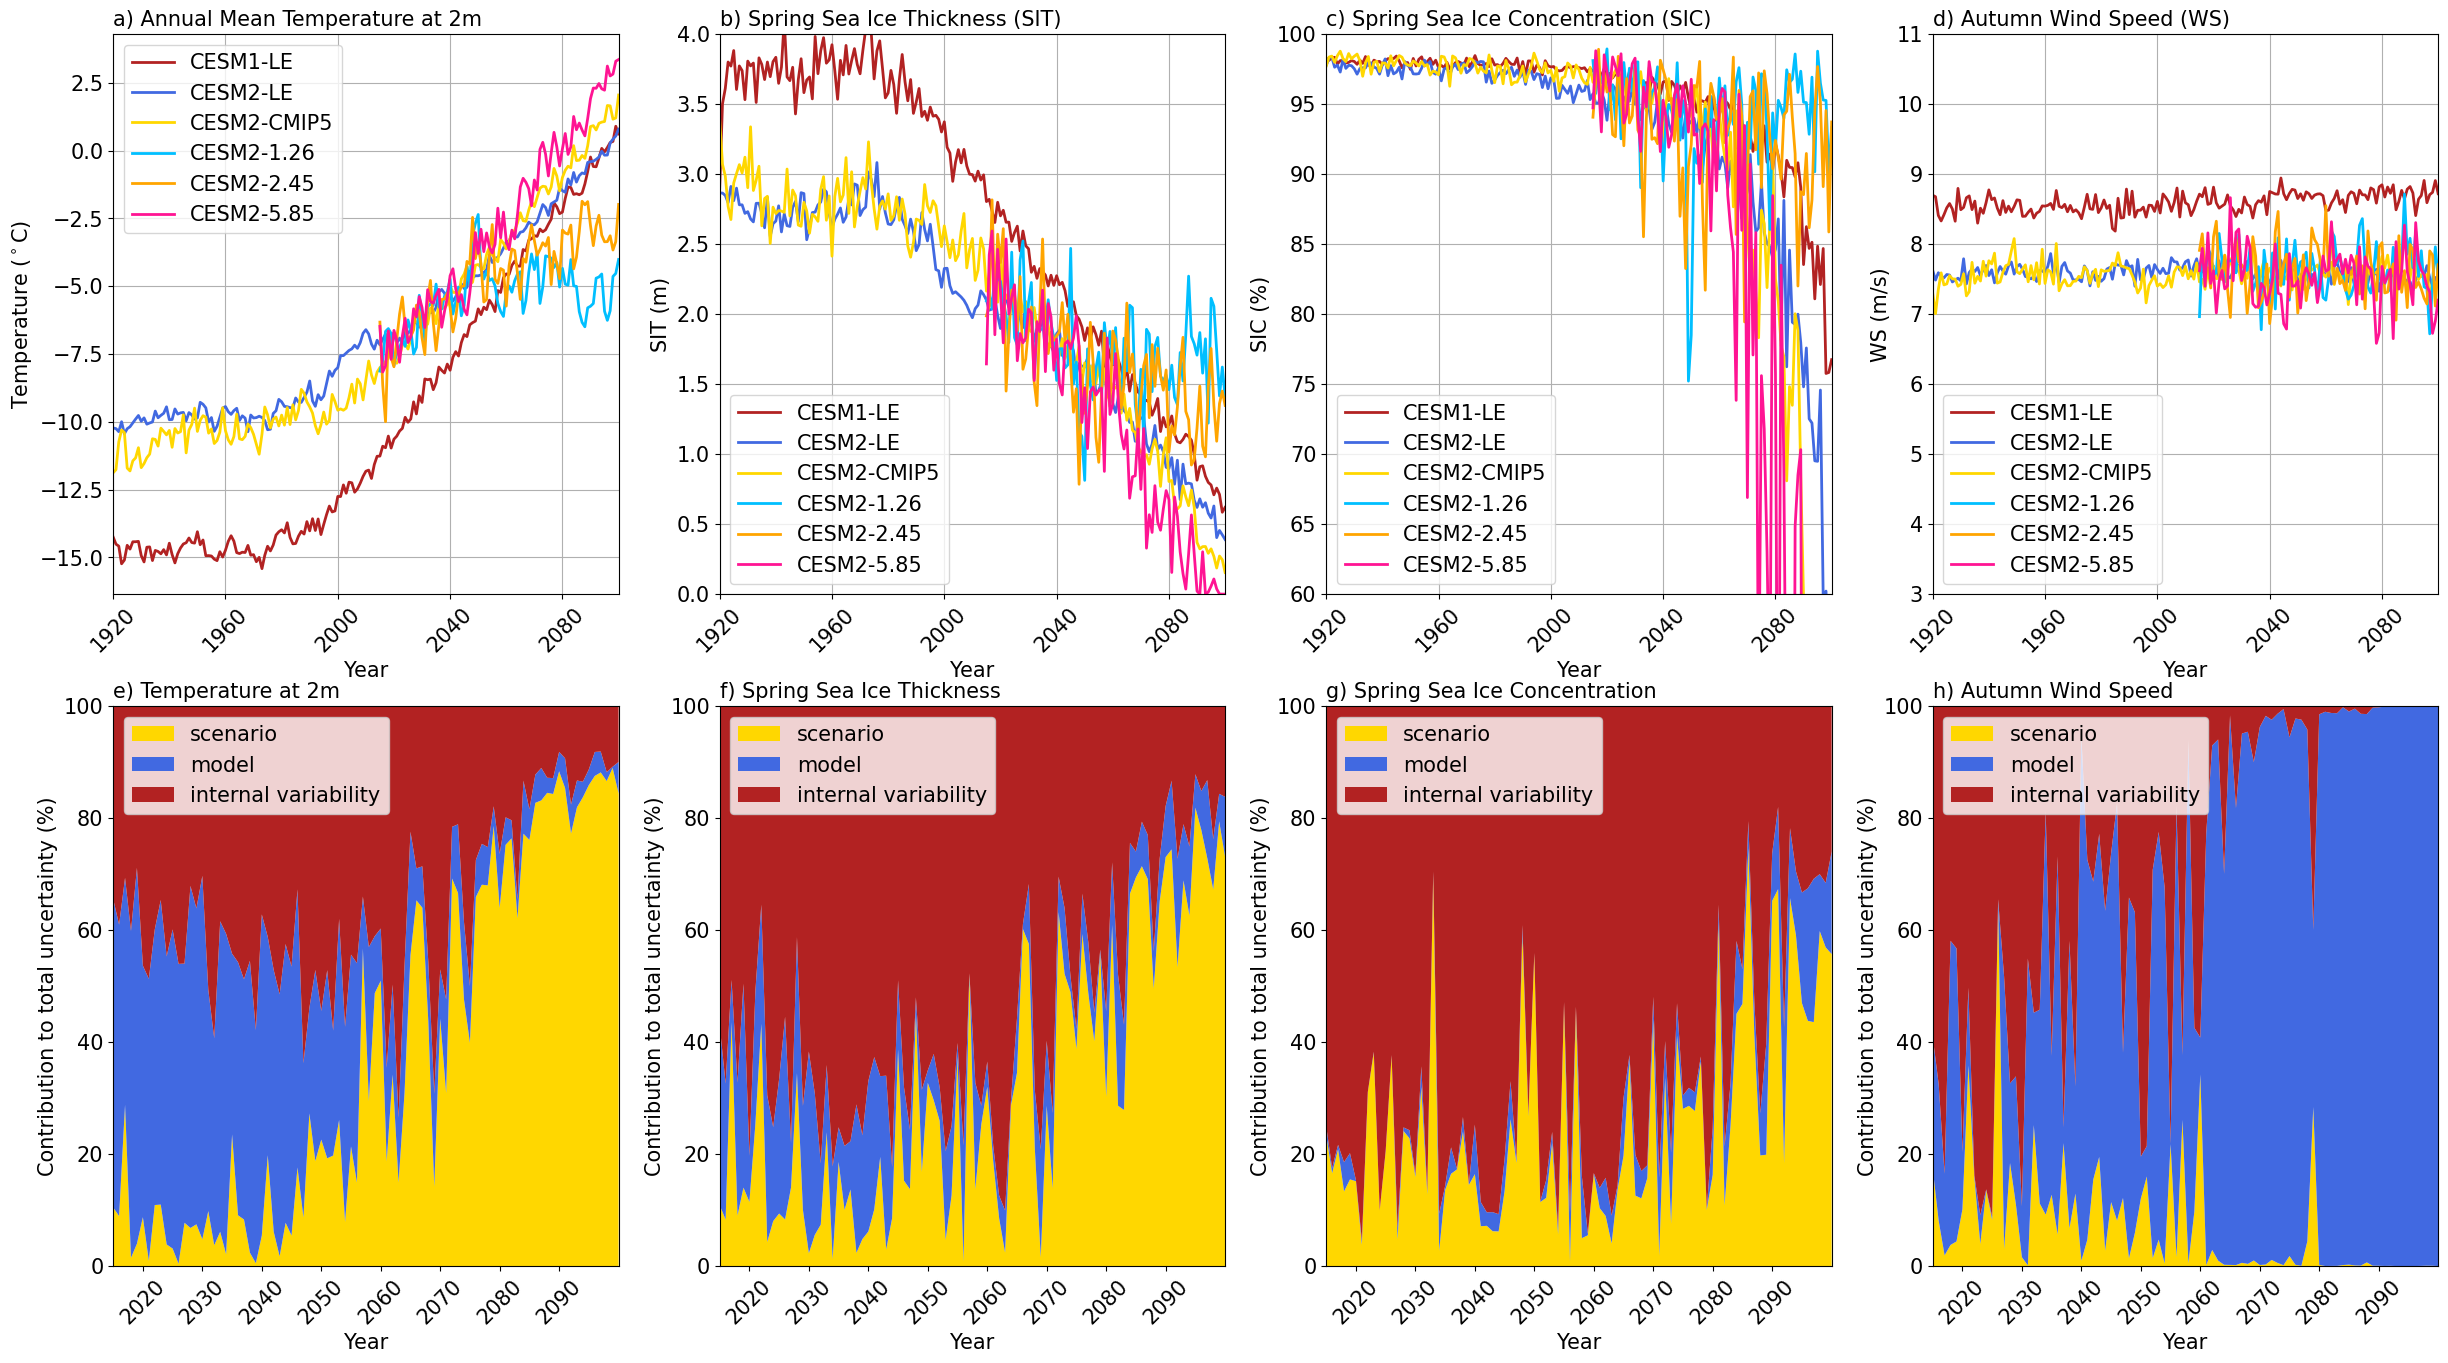

In [155]:
# create figure
#fig = plt.figure(figsize=(20,12))
fig = plt.figure(figsize=(30,16))
# now loop through months to create subpanels
fout = 'fig_8_utq_uncertainty'

# Make subplot - note it's nrow x ncol x index (starting upper left)
############
### First grouping: Mean State Comparison
### Plot 1 - T2m ###
ax = fig.add_subplot(2,4,1)
## CESM1-LE
c1 = 'firebrick'
data_avg = temp_cesm1le_yearly.mean(dim='member_id')
ax.plot(years_model,data_avg,color=c1,label='CESM1-LE',linestyle='-',linewidth=2)
## CESM2-LE
c1 = 'royalblue'
data_avg = temp_cesm2le_yearly.mean(dim='member_id')
ax.plot(years_model,data_avg,color=c1,label='CESM2-LE',linestyle='-',linewidth=2)
## CESM2-CMIP5
c1 = 'gold'
data_avg = temp_cesm2cmip5_yearly.mean(dim='member_id')
ax.plot(years_model,data_avg,color=c1,label='CESM2-CMIP5',linestyle='-',linewidth=2)
## MESACLILP
#c1 = 'turquoise'
#data_avg = temp_mesaclip_yearly.mean(dim='member_id')
#ax.plot(years_model,data_avg,color=c1,label='MESACLIP',linestyle='-',linewidth=2)
## CESM2-126
c1 = 'deepskyblue'
data_avg = temp_cesm2_126_yearly.mean(dim='member_id')
ax.plot(years_short,data_avg,color=c1,label='CESM2-1.26',linestyle='-',linewidth=2)
## CESM2-245
c1 = 'orange'
data_avg = temp_cesm2_245_yearly.mean(dim='member_id')
ax.plot(years_short,data_avg,color=c1,label='CESM2-2.45',linestyle='-',linewidth=2)
## CESM2-585
c1 = 'deeppink'
data_avg = temp_cesm2_585_yearly.mean(dim='member_id')
ax.plot(years_short,data_avg,color=c1,label='CESM2-5.85',linestyle='-',linewidth=2)
# modify labels and legend
plt.title('a) Annual Mean Temperature at 2m',loc='left',fontsize=15)
plt.xlabel('Year',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
ax.set_xticks(xticks_ts)
plt.xlim([1920,2100])
plt.ylabel('Temperature ($^\\circ$C)',fontsize=15)
plt.yticks(fontsize=15)
#plt.ylim([-1,100.0])
plt.grid()
plt.legend(loc='upper left', fontsize=15, ncol=1);

### Plot 2 - SIT ###
ax = fig.add_subplot(2,4,2)
## CESM1-LE
c1 = 'firebrick'
data_avg = sit_cesm1le_yearly.mean(dim='member_id')
ax.plot(years_model,data_avg,color=c1,label='CESM1-LE',linestyle='-',linewidth=2)
## CESM2-LE
c1 = 'royalblue'
data_avg = sit_cesm2le_yearly.mean(dim='member_id')
ax.plot(years_model,data_avg,color=c1,label='CESM2-LE',linestyle='-',linewidth=2)
## CESM2-CMIP5
c1 = 'gold'
data_avg = sit_cesm2cmip5_yearly.mean(dim='member_id')
ax.plot(years_model,data_avg,color=c1,label='CESM2-CMIP5',linestyle='-',linewidth=2)
## MESACLILP
#c1 = 'turquoise'
#data_avg = sit_mesaclip_yearly.mean(dim='member_id')
#ax.plot(years_model,data_avg,color=c1,label='MESACLIP',linestyle='-',linewidth=2)
## CESM2-126
c1 = 'deepskyblue'
data_avg = sit_cesm2_126_yearly.mean(dim='member_id')
ax.plot(years_short,data_avg,color=c1,label='CESM2-1.26',linestyle='-',linewidth=2)
## CESM2-245
c1 = 'orange'
data_avg = sit_cesm2_245_yearly.mean(dim='member_id')
ax.plot(years_short,data_avg,color=c1,label='CESM2-2.45',linestyle='-',linewidth=2)
## CESM2-585
c1 = 'deeppink'
data_avg = sit_cesm2_585_yearly.mean(dim='member_id')
ax.plot(years_short,data_avg,color=c1,label='CESM2-5.85',linestyle='-',linewidth=2)
# modify labels and legend
plt.title('b) Spring Sea Ice Thickness (SIT)',loc='left',fontsize=15)
plt.xlabel('Year',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([1920,2100])
ax.set_xticks(xticks_ts)
plt.ylabel('SIT (m)',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([0,4])
plt.grid()
plt.legend(loc='lower left', fontsize=15, ncol=1);

### Plot 3 - SIC ###
ax = fig.add_subplot(2,4,3)
## CESM1-LE
c1 = 'firebrick'
data_avg = sic_cesm1le_yearly.mean(dim='member_id')
ax.plot(years_model,data_avg,color=c1,label='CESM1-LE',linestyle='-',linewidth=2)
## CESM2-LE
c1 = 'royalblue'
data_avg = sic_cesm2le_yearly.mean(dim='member_id')
ax.plot(years_model,data_avg,color=c1,label='CESM2-LE',linestyle='-',linewidth=2)
## CESM2-CMIP5
c1 = 'gold'
data_avg = sic_cesm2cmip5_yearly.mean(dim='member_id')
ax.plot(years_model,data_avg,color=c1,label='CESM2-CMIP5',linestyle='-',linewidth=2)
## MESACLILP
#c1 = 'turquoise'
#data_avg = sic_mesaclip_yearly.mean(dim='member_id')
#ax.plot(years_model,data_avg,color=c1,label='MESACLIP',linestyle='-',linewidth=2)
## CESM2-126
c1 = 'deepskyblue'
data_avg = sic_cesm2_126_yearly.mean(dim='member_id')
ax.plot(years_short,data_avg,color=c1,label='CESM2-1.26',linestyle='-',linewidth=2)
## CESM2-245
c1 = 'orange'
data_avg = sic_cesm2_245_yearly.mean(dim='member_id')
ax.plot(years_short,data_avg,color=c1,label='CESM2-2.45',linestyle='-',linewidth=2)
## CESM2-585
c1 = 'deeppink'
data_avg = sic_cesm2_585_yearly.mean(dim='member_id')
ax.plot(years_short,data_avg,color=c1,label='CESM2-5.85',linestyle='-',linewidth=2)
# modify labels and legend
plt.title('c) Spring Sea Ice Concentration (SIC)',loc='left',fontsize=15)
plt.xlabel('Year',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([1920,2100])
ax.set_xticks(xticks_ts)
plt.ylabel('SIC (%)',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([60,100])
plt.grid()
plt.legend(loc='lower left', fontsize=15, ncol=1);

### Plot 4 - U10 ###
ax = fig.add_subplot(2,4,4)
## CESM1-LE
c1 = 'firebrick'
data_avg = u10_cesm1le_yearly.mean(dim='member_id')
ax.plot(years_model,data_avg,color=c1,label='CESM1-LE',linestyle='-',linewidth=2)
## CESM2-LE
c1 = 'royalblue'
data_avg = u10_cesm2le_yearly.mean(dim='member_id')
ax.plot(years_model,data_avg,color=c1,label='CESM2-LE',linestyle='-',linewidth=2)
## CESM2-CMIP5
c1 = 'gold'
data_avg = u10_cesm2cmip5_yearly.mean(dim='member_id')
ax.plot(years_model,data_avg,color=c1,label='CESM2-CMIP5',linestyle='-',linewidth=2)
## MESACLILP
#c1 = 'turquoise'
#data_avg = u10_mesaclip_yearly.mean(dim='member_id')
#ax.plot(years_model,data_avg,color=c1,label='MESACLIP',linestyle='-',linewidth=2)
## CESM2-126
c1 = 'deepskyblue'
data_avg = u10_cesm2_126_yearly.mean(dim='member_id')
ax.plot(years_short,data_avg,color=c1,label='CESM2-1.26',linestyle='-',linewidth=2)
## CESM2-245
c1 = 'orange'
data_avg = u10_cesm2_245_yearly.mean(dim='member_id')
ax.plot(years_short,data_avg,color=c1,label='CESM2-2.45',linestyle='-',linewidth=2)
## CESM2-585
c1 = 'deeppink'
data_avg = u10_cesm2_585_yearly.mean(dim='member_id')
ax.plot(years_short,data_avg,color=c1,label='CESM2-5.85',linestyle='-',linewidth=2)
# modify labels and legend
plt.title('d) Autumn Wind Speed (WS)',loc='left',fontsize=15)
plt.xlabel('Year',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([1920,2100])
ax.set_xticks(xticks_ts)
plt.ylabel('WS (m/s)',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([3,11])
plt.grid()
plt.legend(loc='lower left', fontsize=15, ncol=1);

############
### Second grouping: Uncertainty
### Plot 5 - T2m ###
ax = fig.add_subplot(2,4,5)
ax.stackplot(years_short,scenario_frac_temp*100,model_frac_temp*100,internal_frac_temp*100,colors=pal,alpha=1)
# modify labels and legend
plt.title('e) Temperature at 2m',loc='left',fontsize=15)
plt.xlabel('Year',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([2015,2100])
ax.set_xticks(xticks_uc)
plt.ylabel('Contribution to total uncertainty (%)',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([0,100])
plt.legend(['scenario','model','internal variability'],loc='upper left', fontsize=15, ncol=1);

### Plot 6 - SIT ###
ax = fig.add_subplot(2,4,6)
ax.stackplot(years_short,scenario_frac_sit*100,model_frac_sit*100,internal_frac_sit*100,colors=pal,alpha=1)
# modify labels and legend
plt.title('f) Spring Sea Ice Thickness',loc='left',fontsize=15)
plt.xlabel('Year',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([2015,2100])
ax.set_xticks(xticks_uc)
plt.ylabel('Contribution to total uncertainty (%)',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([0,100])
plt.legend(['scenario','model','internal variability'],loc='upper left', fontsize=15, ncol=1);

### Plot 7 - SIC ###
ax = fig.add_subplot(2,4,7)
ax.stackplot(years_short,scenario_frac_sic*100,model_frac_sic*100,internal_frac_sic*100,colors=pal,alpha=1)
# modify labels and legend
plt.title('g) Spring Sea Ice Concentration',loc='left',fontsize=15)
plt.xlabel('Year',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([2015,2100])
ax.set_xticks(xticks_uc)
plt.ylabel('Contribution to total uncertainty (%)',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([0,100])
plt.legend(['scenario','model','internal variability'],loc='upper left', fontsize=15, ncol=1);

### Plot 8 - WS ###
ax = fig.add_subplot(2,4,8)
ax.stackplot(years_short,scenario_frac_u10*100,model_frac_u10*100,internal_frac_u10*100,colors=pal,alpha=1)
# modify labels and legend
plt.title('h) Autumn Wind Speed',loc='left',fontsize=15)
plt.xlabel('Year',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([2015,2100])
ax.set_xticks(xticks_uc)
plt.ylabel('Contribution to total uncertainty (%)',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([0,100])
plt.legend(['scenario','model','internal variability'],loc='upper left', fontsize=15, ncol=1);

############

# Finalize figure and save
#fig = plt.savefig(fout+'.png', bbox_inches='tight', dpi=200)
#fig = plt.savefig(dir_out+fout+'.png', bbox_inches='tight', dpi=200)

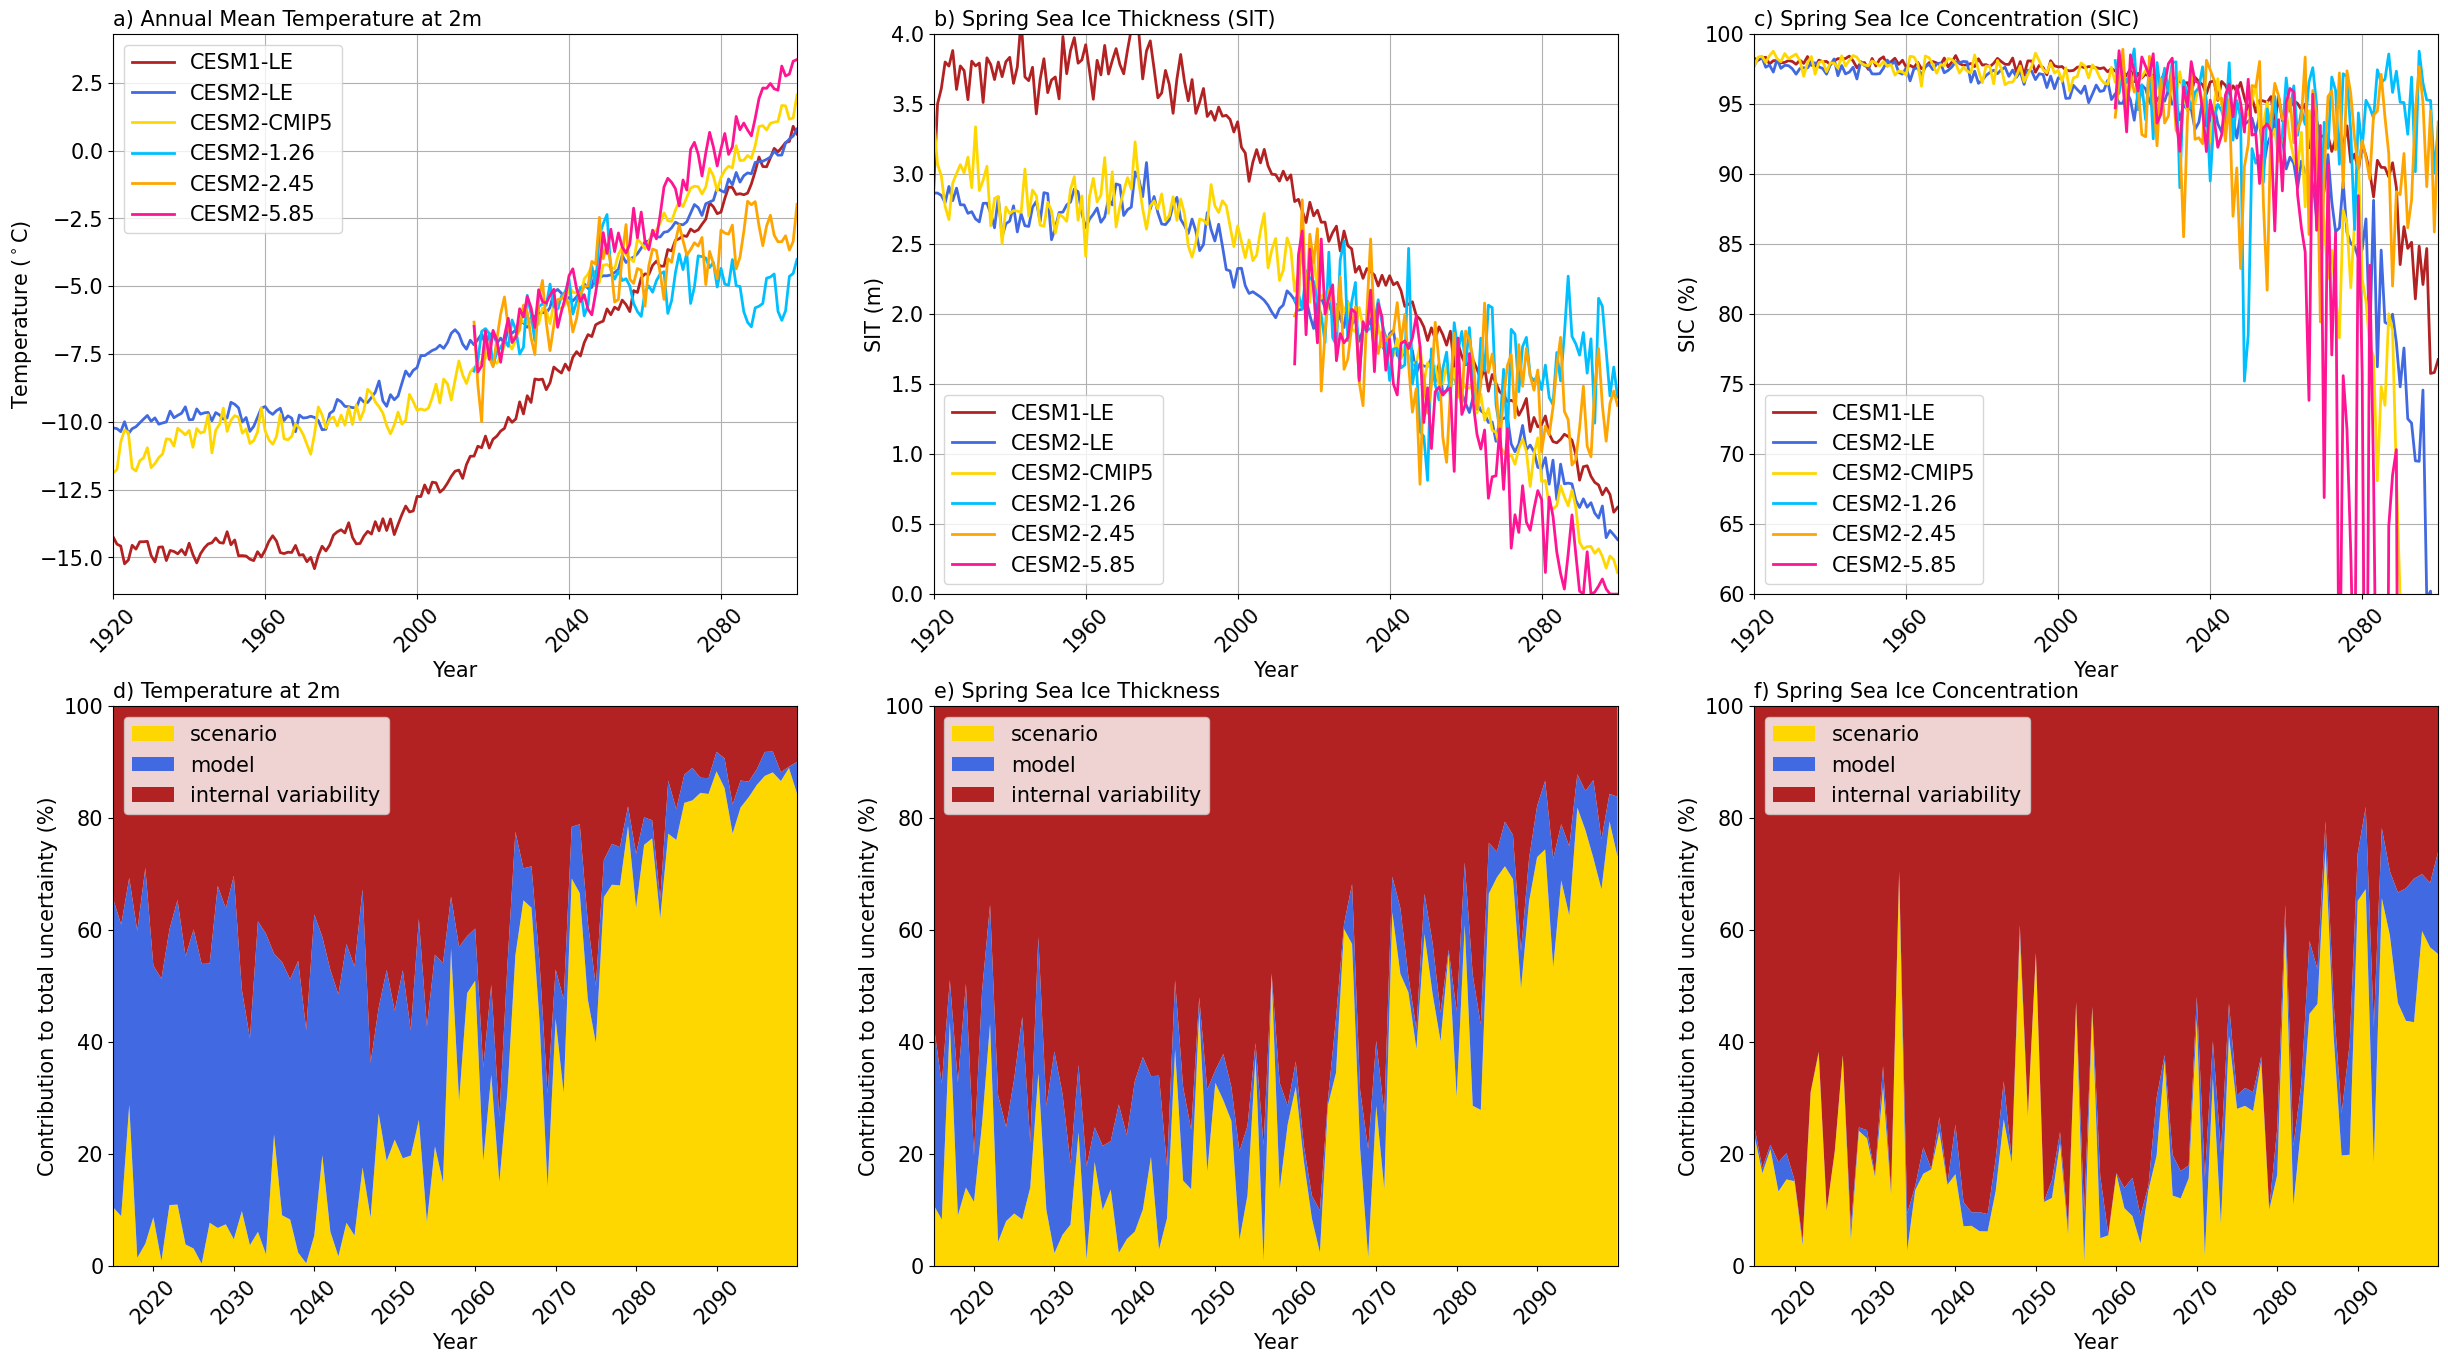

In [156]:
# create figure
#fig = plt.figure(figsize=(20,12))
fig = plt.figure(figsize=(30,16))
# now loop through months to create subpanels
fout = 'fig_8_utq_uncertainty'

# Make subplot - note it's nrow x ncol x index (starting upper left)
############
### First grouping: Mean State Comparison
### Plot 1 - T2m ###
ax = fig.add_subplot(2,3,1)
## CESM1-LE
c1 = 'firebrick'
data_avg = temp_cesm1le_yearly.mean(dim='member_id')
ax.plot(years_model,data_avg,color=c1,label='CESM1-LE',linestyle='-',linewidth=2)
## CESM2-LE
c1 = 'royalblue'
data_avg = temp_cesm2le_yearly.mean(dim='member_id')
ax.plot(years_model,data_avg,color=c1,label='CESM2-LE',linestyle='-',linewidth=2)
## CESM2-CMIP5
c1 = 'gold'
data_avg = temp_cesm2cmip5_yearly.mean(dim='member_id')
ax.plot(years_model,data_avg,color=c1,label='CESM2-CMIP5',linestyle='-',linewidth=2)
## MESACLILP
#c1 = 'turquoise'
#data_avg = temp_mesaclip_yearly.mean(dim='member_id')
#ax.plot(years_model,data_avg,color=c1,label='MESACLIP',linestyle='-',linewidth=2)
## CESM2-126
c1 = 'deepskyblue'
data_avg = temp_cesm2_126_yearly.mean(dim='member_id')
ax.plot(years_short,data_avg,color=c1,label='CESM2-1.26',linestyle='-',linewidth=2)
## CESM2-245
c1 = 'orange'
data_avg = temp_cesm2_245_yearly.mean(dim='member_id')
ax.plot(years_short,data_avg,color=c1,label='CESM2-2.45',linestyle='-',linewidth=2)
## CESM2-585
c1 = 'deeppink'
data_avg = temp_cesm2_585_yearly.mean(dim='member_id')
ax.plot(years_short,data_avg,color=c1,label='CESM2-5.85',linestyle='-',linewidth=2)
# modify labels and legend
plt.title('a) Annual Mean Temperature at 2m',loc='left',fontsize=15)
plt.xlabel('Year',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
ax.set_xticks(xticks_ts)
plt.xlim([1920,2100])
plt.ylabel('Temperature ($^\\circ$C)',fontsize=15)
plt.yticks(fontsize=15)
#plt.ylim([-1,100.0])
plt.grid()
plt.legend(loc='upper left', fontsize=15, ncol=1);

### Plot 2 - SIT ###
ax = fig.add_subplot(2,3,2)
## CESM1-LE
c1 = 'firebrick'
data_avg = sit_cesm1le_yearly.mean(dim='member_id')
ax.plot(years_model,data_avg,color=c1,label='CESM1-LE',linestyle='-',linewidth=2)
## CESM2-LE
c1 = 'royalblue'
data_avg = sit_cesm2le_yearly.mean(dim='member_id')
ax.plot(years_model,data_avg,color=c1,label='CESM2-LE',linestyle='-',linewidth=2)
## CESM2-CMIP5
c1 = 'gold'
data_avg = sit_cesm2cmip5_yearly.mean(dim='member_id')
ax.plot(years_model,data_avg,color=c1,label='CESM2-CMIP5',linestyle='-',linewidth=2)
## MESACLILP
#c1 = 'turquoise'
#data_avg = sit_mesaclip_yearly.mean(dim='member_id')
#ax.plot(years_model,data_avg,color=c1,label='MESACLIP',linestyle='-',linewidth=2)
## CESM2-126
c1 = 'deepskyblue'
data_avg = sit_cesm2_126_yearly.mean(dim='member_id')
ax.plot(years_short,data_avg,color=c1,label='CESM2-1.26',linestyle='-',linewidth=2)
## CESM2-245
c1 = 'orange'
data_avg = sit_cesm2_245_yearly.mean(dim='member_id')
ax.plot(years_short,data_avg,color=c1,label='CESM2-2.45',linestyle='-',linewidth=2)
## CESM2-585
c1 = 'deeppink'
data_avg = sit_cesm2_585_yearly.mean(dim='member_id')
ax.plot(years_short,data_avg,color=c1,label='CESM2-5.85',linestyle='-',linewidth=2)
# modify labels and legend
plt.title('b) Spring Sea Ice Thickness (SIT)',loc='left',fontsize=15)
plt.xlabel('Year',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([1920,2100])
ax.set_xticks(xticks_ts)
plt.ylabel('SIT (m)',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([0,4])
plt.grid()
plt.legend(loc='lower left', fontsize=15, ncol=1);

### Plot 3 - SIC ###
ax = fig.add_subplot(2,3,3)
## CESM1-LE
c1 = 'firebrick'
data_avg = sic_cesm1le_yearly.mean(dim='member_id')
ax.plot(years_model,data_avg,color=c1,label='CESM1-LE',linestyle='-',linewidth=2)
## CESM2-LE
c1 = 'royalblue'
data_avg = sic_cesm2le_yearly.mean(dim='member_id')
ax.plot(years_model,data_avg,color=c1,label='CESM2-LE',linestyle='-',linewidth=2)
## CESM2-CMIP5
c1 = 'gold'
data_avg = sic_cesm2cmip5_yearly.mean(dim='member_id')
ax.plot(years_model,data_avg,color=c1,label='CESM2-CMIP5',linestyle='-',linewidth=2)
## MESACLILP
#c1 = 'turquoise'
#data_avg = sic_mesaclip_yearly.mean(dim='member_id')
#ax.plot(years_model,data_avg,color=c1,label='MESACLIP',linestyle='-',linewidth=2)
## CESM2-126
c1 = 'deepskyblue'
data_avg = sic_cesm2_126_yearly.mean(dim='member_id')
ax.plot(years_short,data_avg,color=c1,label='CESM2-1.26',linestyle='-',linewidth=2)
## CESM2-245
c1 = 'orange'
data_avg = sic_cesm2_245_yearly.mean(dim='member_id')
ax.plot(years_short,data_avg,color=c1,label='CESM2-2.45',linestyle='-',linewidth=2)
## CESM2-585
c1 = 'deeppink'
data_avg = sic_cesm2_585_yearly.mean(dim='member_id')
ax.plot(years_short,data_avg,color=c1,label='CESM2-5.85',linestyle='-',linewidth=2)
# modify labels and legend
plt.title('c) Spring Sea Ice Concentration (SIC)',loc='left',fontsize=15)
plt.xlabel('Year',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([1920,2100])
ax.set_xticks(xticks_ts)
plt.ylabel('SIC (%)',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([60,100])
plt.grid()
plt.legend(loc='lower left', fontsize=15, ncol=1);

############
### Second grouping: Uncertainty
### Plot 5 - T2m ###
ax = fig.add_subplot(2,3,4)
ax.stackplot(years_short,scenario_frac_temp*100,model_frac_temp*100,internal_frac_temp*100,colors=pal,alpha=1)
# modify labels and legend
plt.title('d) Temperature at 2m',loc='left',fontsize=15)
plt.xlabel('Year',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([2015,2100])
ax.set_xticks(xticks_uc)
plt.ylabel('Contribution to total uncertainty (%)',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([0,100])
plt.legend(['scenario','model','internal variability'],loc='upper left', fontsize=15, ncol=1);

### Plot 6 - SIT ###
ax = fig.add_subplot(2,3,5)
ax.stackplot(years_short,scenario_frac_sit*100,model_frac_sit*100,internal_frac_sit*100,colors=pal,alpha=1)
# modify labels and legend
plt.title('e) Spring Sea Ice Thickness',loc='left',fontsize=15)
plt.xlabel('Year',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([2015,2100])
ax.set_xticks(xticks_uc)
plt.ylabel('Contribution to total uncertainty (%)',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([0,100])
plt.legend(['scenario','model','internal variability'],loc='upper left', fontsize=15, ncol=1);

### Plot 7 - SIC ###
ax = fig.add_subplot(2,3,6)
ax.stackplot(years_short,scenario_frac_sic*100,model_frac_sic*100,internal_frac_sic*100,colors=pal,alpha=1)
# modify labels and legend
plt.title('f) Spring Sea Ice Concentration',loc='left',fontsize=15)
plt.xlabel('Year',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([2015,2100])
ax.set_xticks(xticks_uc)
plt.ylabel('Contribution to total uncertainty (%)',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([0,100])
plt.legend(['scenario','model','internal variability'],loc='upper left', fontsize=15, ncol=1);

############

# Finalize figure and save
fig = plt.savefig(fout+'.png', bbox_inches='tight', dpi=200)
fig = plt.savefig(dir_out+fout+'.png', bbox_inches='tight', dpi=200)